# TDSE Laboratory 1 - Stellar Luminosity

#### 1. Environment establishment

The required libraries (NumPy and Matplotlib) are imported, and the stellar mass and luminosity data are loaded as NumPy arrays, verifying their dimensions and value ranges.

In [148]:
# 1st Section: Establishing the environment.
import sys
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

print("Python version:", sys.version)
print("NumPy version:", np.__version__)
print("Matplotlib version:", matplotlib.__version__)


Python version: 3.12.0 (tags/v3.12.0:0fb18b0, Oct  2 2023, 13:03:39) [MSC v.1935 64 bit (AMD64)]
NumPy version: 2.5.1
Matplotlib version: 3.11.1


In [149]:
# Stellar mass (in solar masses) and luminosity (in solar luminosities).
mass = np.array([0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4])
luminosity = np.array([0.15, 0.35, 1.00, 2.30, 4.10, 7.00, 11.2, 17.5, 25.0, 35.0])

print("mass shape:", mass.shape)
print("luminosity shape:", luminosity.shape)
print("mass range:", mass.min(), "to", mass.max())
print("luminosity range:", luminosity.min(), "to", luminosity.max())

mass shape: (10,)
luminosity shape: (10,)
mass range: 0.6 to 2.4
luminosity range: 0.15 to 35.0


#### 2. Initial Exploration

The mass–luminosity relationship is plotted, revealing a strongly nonlinear (convex) trend, which suggests that a straight-line model is insufficient to accurately represent the data.

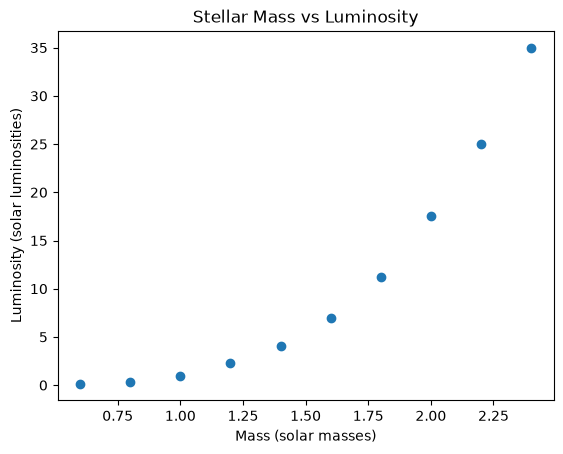

In [150]:
# 2nd Section: Exploring before modeling.
plt.figure()
plt.scatter(mass, luminosity)
plt.xlabel("Mass (solar masses)")
plt.ylabel("Luminosity (solar luminosities)")
plt.title("Stellar Mass vs Luminosity")
plt.show()

#### Observed Relation Description

- Between mass = 0.6 and mass = 2.4 (value scaled 4 times), luminosity increases from 0.15 to 35.0. This is consistent with the real mass–luminosity relationship of main-sequence stars, where \(L \propto M^{a}\), with \(a\) typically ranging between 3 and 4—a strongly nonlinear and convex relationship.

- Is a straight line an appropriate model? Not entirely. A straight line can only capture a constant rate of change (a fixed slope). In this case, the slope of the curve increases as the stellar mass grows. Therefore, a single straight line will: underestimate the luminosity at the high-mass end (where the curve becomes steeper), and overestimate the luminosity at the low-mass end (where the curve is flatter).

#### 3. Implement the learning algorithm

The prediction cost (MSE), gradient computation, and gradient descent—are implemented from scratch in a fully vectorized manner, allowing them to support any number of input features.

In [151]:
# 3rd Section: Implementing the learning algorithm.
def predict(X, w, b):
    """Vectorized prediction: y_hat = X @ w + b.
    X: shape (m, n) -- m examples, n features.
    w: shape (n,)   -- one weight per feature.
    b: scalar bias.
    """
    return X @ w + b

def compute_cost(X, y, w, b):
    """Mean squared error cost, J(w,b) = (1/2m) * sum((y_hat - y)^2)."""
    m = X.shape[0]
    y_hat = predict(X, w, b)
    error = y_hat - y
    cost = (error @ error) / (2 * m)
    return cost

def compute_gradient(X, y, w, b):
    """Vectorized gradients of J with respect to w and b."""
    m = X.shape[0]
    y_hat = predict(X, w, b)
    error = y_hat - y
    dj_dw = (X.T @ error) / m
    dj_db = np.sum(error) / m
    return dj_dw, dj_db

def gradient_descent(X, y, w_init, b_init, alpha, num_iterations, print_progress=True):
    """Run gradient descent, returning learned parameters and cost history."""
    w = w_init.copy()
    b = b_init
    history_it = []
    history_cost = []

    for i in range(num_iterations):
        dj_dw, dj_db = compute_gradient(X, y, w, b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        cost = compute_cost(X, y, w, b)
        history_it.append(i)
        history_cost.append(cost)

        if print_progress and (i % max(1, num_iterations // 10) == 0 or i == num_iterations - 1):
            print(f"Iteration {i:5d}: cost = {cost:10.6f}")

    return w, b, history_it, history_cost

In [152]:
X_check = mass.reshape(-1, 1)   # shape (10, 1) -- una sola feature: mass
w_check = np.zeros(X_check.shape[1])
b_check = 0.0

print("predict shape:", predict(X_check, w_check, b_check).shape)
print("cost at w=0,b=0:", compute_cost(X_check, luminosity, w_check, b_check))

dj_dw_check, dj_db_check = compute_gradient(X_check, luminosity, w_check, b_check)
print("dj_dw:", dj_dw_check, " dj_db:", dj_db_check)

predict shape: (10,)
cost at w=0,b=0: 117.69675
dj_dw: [-21.523]  dj_db: -10.36


#### 4. Linear model training

The model \(f(\text{mass}) = w \cdot \text{mass} + b\) is trained using the previously implemented functions. Although the optimization converges successfully, the resulting fit exhibits systematic errors—underestimating luminosity at the low- and high-mass extremes while overestimating it in the middle—clearly indicating underfitting.

In [153]:
# 4th Section: Training a linear model.
X_linear = mass.reshape(-1, 1)   # shape (10, 1)

w_init = np.zeros(X_linear.shape[1])
b_init = 0.0
alpha = 0.05
num_iterations = 3000

w_linear, b_linear, it_linear, cost_linear = gradient_descent(
    X_linear, luminosity, w_init, b_init, alpha, num_iterations
)

print("Learned parameters (linear model):")
print(f"  w = {w_linear[0]:.4f}")
print(f"  b = {b_linear:.4f}")
print(f"  final cost = {cost_linear[-1]:.4f}")


Iteration     0: cost =  91.632572
Iteration   300: cost =  11.333595
Iteration   600: cost =   9.884385
Iteration   900: cost =   9.800325
Iteration  1200: cost =   9.795449
Iteration  1500: cost =   9.795166
Iteration  1800: cost =   9.795149
Iteration  2100: cost =   9.795149
Iteration  2400: cost =   9.795148
Iteration  2700: cost =   9.795148
Iteration  2999: cost =   9.795148
Learned parameters (linear model):
  w = 18.1303
  b = -16.8354
  final cost = 9.7951


#### 5. Plynomial model training

The exact same functions are reused, with the only change being the input matrix, which is expanded to include both mass and mass² as features. This significantly reduces the final cost, and the resulting curve follows the data much more closely.

In [154]:
# 5th Section: Training a plynomial model.
X_poly = np.column_stack([mass, mass**2])   # shape (10, 2)
print("X_poly shape:", X_poly.shape)
print("Feature ranges: mass in", (mass.min(), mass.max()),
      " mass^2 in", (X_poly[:, 1].min(), X_poly[:, 1].max()))

X_poly shape: (10, 2)
Feature ranges: mass in (np.float64(0.6), np.float64(2.4))  mass^2 in (np.float64(0.36), np.float64(5.76))


In [155]:
w_init_poly = np.zeros(X_poly.shape[1])
b_init_poly = 0.0
alpha_poly = 0.05
num_iterations_poly = 30000

w_poly, b_poly, it_poly, cost_poly = gradient_descent(
    X_poly, luminosity, w_init_poly, b_init_poly, alpha_poly, num_iterations_poly
)

print("Learned parameters (polynomial model):")
print(f"  w_mass    = {w_poly[0]:.4f}")
print(f"  w_mass_sq = {w_poly[1]:.4f}")
print(f"  b         = {b_poly:.4f}")
print(f"  final cost = {cost_poly[-1]:.4f}")

Iteration     0: cost =  26.799313
Iteration  3000: cost =   0.823503
Iteration  6000: cost =   0.402211
Iteration  9000: cost =   0.330049
Iteration 12000: cost =   0.317688
Iteration 15000: cost =   0.315571
Iteration 18000: cost =   0.315208
Iteration 21000: cost =   0.315146
Iteration 24000: cost =   0.315136
Iteration 27000: cost =   0.315134
Iteration 29999: cost =   0.315133
Learned parameters (polynomial model):
  w_mass    = -26.8091
  w_mass_sq = 14.9799
  b         = 11.9256
  final cost = 0.3151


#### 6. Compare the models

The training costs and residuals of both models are compared, confirming that the polynomial model provides a better fit to the observed data. However, it is important to note that a lower training error alone does not establish the scientific validity of the model.

In [156]:
# 6th Section: Comparing each model.
print("Final cost -- linear model:     ", cost_linear[-1])
print("Final cost -- polynomial model: ", cost_poly[-1])
print("Ratio (linear / polynomial):    ", cost_linear[-1] / cost_poly[-1])

Final cost -- linear model:      9.795148484860032
Final cost -- polynomial model:  0.31513339789653755
Ratio (linear / polynomial):     31.08254647156094


#### 7. Evidence boundaries

Predictions are generated for one point within the observed data range (mass = 1.3) and another far outside it (mass = 5.0), illustrating that extrapolations beyond the available data are not supported by empirical evidence, regardless of which model appears to produce more reasonable predictions.

In [157]:
# 7th Section: Testing the boundaries of the evidence.
test_masses = np.array([1.3, 5.0])

for m_test in test_masses:
    X_lin_test = np.array([[m_test]])
    X_poly_test = np.array([[m_test, m_test**2]])

    pred_lin_test = predict(X_lin_test, w_linear, b_linear)[0]
    pred_poly_test = predict(X_poly_test, w_poly, b_poly)[0]

    in_range = "inside" if mass.min() <= m_test <= mass.max() else "OUTSIDE"
    print(f"mass = {m_test} ({in_range} observed range [{mass.min()}, {mass.max()}])")
    print(f"    linear prediction:     {pred_lin_test:8.3f}")
    print(f"    polynomial prediction: {pred_poly_test:8.3f}")

mass = 1.3 (inside observed range [0.6, 2.4])
    linear prediction:        6.734
    polynomial prediction:    2.390
mass = 5.0 (OUTSIDE observed range [0.6, 2.4])
    linear prediction:       73.816
    polynomial prediction:  252.376


#### 8. Reflect on AI - Answer the following questions after completing the technical work:

##### 1. What does this regression experiment reveal—and what does it fail to reveal—about how more advanced AI systems learn?

##### What this experiment reveals

This experiment illustrates the core principles behind supervised machine learning. First, it shows that learning from data consists of iteratively adjusting model parameters to minimize a loss function, the same optimization principle used by modern neural networks, although at a much larger scale. It also demonstrates that the quality of the data representation is as important as the optimization algorithm itself, since introducing the mass^2 feature significantly improved the model without changing the learning procedure. Finally, it highlights that achieving a low training error does not necessarily imply that a model is scientifically valid or capable of generalizing well, emphasizing a fundamental challenge in modern machine learning.

##### What this experiment does not reveal

Despite these insights, the experiment remains a highly simplified example of machine learning. The polynomial representation was manually designed, whereas modern deep learning models automatically learn hierarchical feature representations from raw data. In addition, the model lacks capabilities such as language understanding, symbolic reasoning, and long-term memory, which characterize large language models (LLMs). Finally, while the experiment shows the risks of extrapolation beyond the training data, this challenge becomes significantly more complex in the high-dimensional settings of contemporary AI systems.

##### 2. Do you think Artificial General Intelligence is achievable? Explain what you understand by AGI and why you believe it is—or is not—reachable.

Optimists of scaling Supporters of this view argue that AGI-like capabilities will emerge primarily by scaling existing architectures through larger datasets, more parameters, and greater computational resources, while architecture skeptics holds that current AI systems still lack essential qualitative capabilities such as robust causal reasoning, long term planning, and a deeper understanding of the physical world that are unlikely to emerge through scaling alone. On the other side, definition skeptics question whether AGI is even a well-defined or measurable concept, arguing that the debate is as much about the meaning of "intelligence" as it is about technical progress.

##### 3. Could AGI emerge primarily by scaling neural networks with more GPUs, data, and parameters? Or will it require fundamentally different architectures, learning mechanisms, theories, or ways of interacting with the world?

I believe that scaling, while an important factor, is not sufficient on its own to achieve the kind of reasoning expected from an AGI. This laboratory exercise provides a useful analogy: increasing the number of training iterations or adjusting the learning rate of the linear model would never have enabled it to capture the curvature of the stellar mass luminosity relationship. No matter how much the training was "scaled," a straight line remained a straight line. The key improvement came from changing the input representation by introducing the \( \text{mass}^2 \) feature.

I suspect that a similar principle applies at a much larger scale. Continuously increasing the number of parameters, the amount of training data, and the available computational resources within the same autoregressive architecture improves what the model already does well, but it does not necessarily lead to qualitatively new capabilities such as robust causal reasoning or a deeper understanding of the physical world.

Scaling will likely remain a necessary component in the development of more capable AI systems, but it is unlikely to be sufficient on its own. Reaching genuinely general reasoning will probably require architectural innovations, whether through world models, neuro symbolic reasoning, or other approaches that have yet to be fully explored.

##### 4. One question about AI-driven systems that I want to explore during the semester is: 

1. Could quantum computing provide a real advantage in the training or reasoning of AI models?

2. At which stages of AI development could quantum computing be applied in the short to medium term, and what hardware limitations prevent this today?